<a href="https://colab.research.google.com/github/sam01149/studikasus_webinar/blob/main/SmartPhone_Segmentation_CRISPMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentasi Pelanggan Smartphone — CRISP-DM

## Framework: CRISP-DM (Cross Industry Standard Process for Data Mining)

Notebook ini mendokumentasikan seluruh siklus analitik menggunakan framework CRISP-DM,
dari pemahaman bisnis hingga deployment model ke data calon pembeli baru.

---

```
Business Understanding → Data Understanding → Data Preparation
        ↓                                             ↓
    Deployment    ←    Evaluation    ←    Modeling
```

# FASE 1 — Business Understanding

> Mendefinisikan tujuan bisnis, kriteria keberhasilan, sumber daya, risiko, dan terminologi sebelum menyentuh data.

---

## 1.1 Define Business Objectives

Perusahaan akan meluncurkan lini smartphone baru dalam waktu dekat. Agar peluncuran menghasilkan penjualan cepat tanpa akumulasi stok, diperlukan identifikasi segmen pelanggan yang paling berpotensi membeli — sehingga anggaran pemasaran dapat diarahkan secara presisi.

**Tujuan bisnis yang ingin dicapai:**
- Meningkatkan pendapatan pasca-peluncuran minimal **150% dari baseline**.
- Meminimalkan stok produk yang tidak terjual.
- Mengidentifikasi segmen pelanggan target untuk pemasaran yang tepat sasaran.

## 1.2 Assess Current Situation

- Data historis pelanggan tersedia dalam `DS_smartPhone.csv` (5.000 baris, 11 kolom).
- Data calon pembeli baru tersedia dalam `DS_smartphoneNewLaunch.csv` (473 baris, tanpa label).
- Distribusi kelas target diketahui imbalanced — Late Majority mendominasi (~51%).
- Stack yang digunakan: Python 3, scikit-learn, pandas, matplotlib, seaborn.

**Terminologi:**

| Istilah | Definisi |
|---|---|
| `Smartphone_Adoption` | Label target: segmen adopsi smartphone pelanggan |
| Innovator | Pembeli pertama, toleran risiko tinggi, aktif cari info baru |
| Early Adopter | Cepat beli setelah validasi awal, berpengaruh ke jaringan |
| Early Majority | Butuh bukti sosial, beli setelah early adopter |
| Late Majority | Skeptis, beli ketika sudah mainstream atau ada diskon |

## 1.3 Formulate Data Mining Problem

Membangun model klasifikasi multiclass yang memprediksi segmen `Smartphone_Adoption` dari profil pelanggan historis, kemudian melakukan scoring terhadap daftar calon pembeli baru.

**Jenis problem:** Supervised Learning — Multiclass Classification  
**Fitur input:** 8 fitur kategorikal + 1 fitur numerik (Age)  
**Target output:** salah satu dari 4 segmen adopsi

## 1.4 Determine Project Objectives

Kriteria keberhasilan teknis yang harus dipenuhi model:

| Metrik | Threshold Minimum |
|---|---|
| Accuracy | > 75% |
| F1-Score (weighted) | > 75% |
| Precision (weighted) | > 75% |
| Recall (weighted) | > 50% |

## 1.5 Plan Project

**Scope:** Seluruh siklus CRISP-DM dari data historis hingga scoring data baru.

**Risiko yang diidentifikasi:**
- Model tidak mencapai threshold metrik → iterasi ke fase Data Preparation atau Modeling.
- Distribusi kelas imbalanced → perlu strategi `class_weight='balanced'`.
- Data calon pembeli baru memiliki distribusi berbeda (distribution shift) → prediksi bias.

**Deliverable:** File `target_prioritas_marketing.csv` berisi daftar calon pembeli dengan segmen prediksi, siap dikirimkan ke tim marketing.

# FASE 2 — Data Understanding

> Mengeksplorasi data mentah: struktur, kualitas, distribusi, dan relasi antar fitur terhadap target.

---

## 2.1 Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

CATEGORY_COLS = ['Payment_Method', 'Website_Activity', 'Bought_Digital_Media_18Mo',
                 'Gender', 'Bought_Electronics_12Mo', 'Bought_Digital',
                 'Browsed_Electronics_12Mo', 'Marital_Status']
NUMERIC_COLS  = ['Age']
TARGET        = 'Smartphone_Adoption'
PRIORITY_SEGS = ['Innovator', 'Early Adopter']
ORDER         = ['Innovator', 'Early Adopter', 'Early Majority', 'Late Majority']
PALETTE       = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']

print('Library berhasil diload.')

Library berhasil diload.


## 2.2 Load Data

In [6]:
df = pd.read_csv('/content/sample_data/DS_smartPhone.csv', delimiter=';')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
df.head()

Shape: (5000, 11)
Missing values: 0
Duplicate rows: 0


,User_ID,Smartphone_Adoption,Payment_Method,Website_Activity,Bought_Digital_Media_18Mo,Gender,Bought_Electronics_12Mo,Bought_Digital,Browsed_Electronics_12Mo,Marital_Status,Age
0,9552,Early Adopter,Monthly Billing,Seldom,No,M,No,Yes,Yes,M,66
1,6757,Early Adopter,Website Account,Regular,Yes,F,No,Yes,No,S,66
2,3599,Early Adopter,Website Account,Regular,No,F,No,Yes,Yes,S,66
3,6811,Early Adopter,Bank Transfer,Seldom,No,F,Yes,Yes,Yes,M,19
4,4104,Early Adopter,Website Account,Regular,No,M,No,Yes,Yes,S,66


## 2.3 Inspeksi Struktur Data

In [7]:
df.info()
print('\nStatistik deskriptif fitur numerik:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   User_ID                    5000 non-null   int64 
 1   Smartphone_Adoption        5000 non-null   object
 2   Payment_Method             5000 non-null   object
 3   Website_Activity           5000 non-null   object
 4   Bought_Digital_Media_18Mo  5000 non-null   object
 5   Gender                     5000 non-null   object
 6   Bought_Electronics_12Mo    5000 non-null   object
 7   Bought_Digital             5000 non-null   object
 8   Browsed_Electronics_12Mo   5000 non-null   object
 9   Marital_Status             5000 non-null   object
 10  Age                        5000 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 429.8+ KB

Statistik deskriptif fitur numerik:


,User_ID,Age
count,5000.000000,5000.000000
mean,5147.914200,45.044400
std,2140.311243,17.096376
min,1003.000000,16.000000
25%,3503.750000,31.000000
50%,4617.500000,46.000000
75%,6696.000000,63.000000
max,9982.000000,66.000000


## 2.4 Data Quality Assessment

Pemeriksaan kualitas data mencakup 6 aspek: **Missing Values, Redundant (duplikasi), Inconsistencies, Outliers, Noisy, dan distribusi umum.**

In [8]:
# 1. Missing values
print('=== 1. Missing Values ===')
print(df.isna().sum())
print(f'Total missing: {df.isna().sum().sum()}  → BERSIH')

# 2. Redundant (duplikasi)
print(f'\n=== 2. Redundant (Duplikasi) ===')
print(f'Jumlah duplikat: {df.duplicated().sum()}  → BERSIH')

# 3. Inconsistencies — cek nilai unik tiap kolom kategorikal
print('\n=== 3. Inconsistencies (Nilai Unik per Kolom Kategorikal) ===')
for col in CATEGORY_COLS:
    print(f'  {col}: {sorted(df[col].unique())}')

# 4. Outliers — IQR method pada kolom numerik (Age)
print('\n=== 4. Outliers (IQR Method) — Age ===')
Q1, Q3 = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
IQR     = Q3 - Q1
outliers = df[(df['Age'] < Q1 - 1.5 * IQR) | (df['Age'] > Q3 + 1.5 * IQR)]
print(f'Batas bawah: {Q1 - 1.5*IQR:.1f} | Batas atas: {Q3 + 1.5*IQR:.1f}')
print(f'Jumlah outlier Age: {len(outliers)}  → {"BERSIH" if len(outliers)==0 else "ADA OUTLIER"}')

# 5. Noisy — cek z-score ekstrem pada Age
from scipy import stats as sp_stats
z_scores = np.abs(sp_stats.zscore(df['Age']))
noisy    = (z_scores > 3).sum()
print(f'\n=== 5. Noisy (Z-Score > 3) — Age ===')
print(f'Jumlah nilai noisy: {noisy}  → {"BERSIH" if noisy==0 else "ADA NOISY DATA"}')

print('\n→ Kesimpulan: Data memenuhi semua standar kualitas. Tidak diperlukan penanganan tambahan.')

=== 1. Missing Values ===
User_ID                      0
Smartphone_Adoption          0
Payment_Method               0
Website_Activity             0
Bought_Digital_Media_18Mo    0
Gender                       0
Bought_Electronics_12Mo      0
Bought_Digital               0
Browsed_Electronics_12Mo     0
Marital_Status               0
Age                          0
dtype: int64
Total missing: 0  → BERSIH

=== 2. Redundant (Duplikasi) ===
Jumlah duplikat: 0  → BERSIH

=== 3. Inconsistencies (Nilai Unik per Kolom Kategorikal) ===
  Payment_Method: ['Bank Transfer', 'Credit Card', 'Monthly Billing', 'Website Account']
  Website_Activity: ['Frequent', 'Regular', 'Seldom']
  Bought_Digital_Media_18Mo: ['No', 'Yes']
  Gender: ['F', 'M']
  Bought_Electronics_12Mo: ['No', 'Yes']
  Bought_Digital: ['No', 'Yes']
  Browsed_Electronics_12Mo: ['No', 'Yes']
  Marital_Status: ['M', 'S']

=== 4. Outliers (IQR Method) — Age ===
Batas bawah: -17.0 | Batas atas: 111.0
Jumlah outlier Age: 0  → BERSIH

=== 

## 2.5 Distribusi Target: `Smartphone_Adoption`

Data sangat imbalanced — Late Majority mendominasi (51.2%), sementara Innovator hanya 3.8%.
Ini menjadi alasan utama penggunaan `class_weight='balanced'` pada semua model.

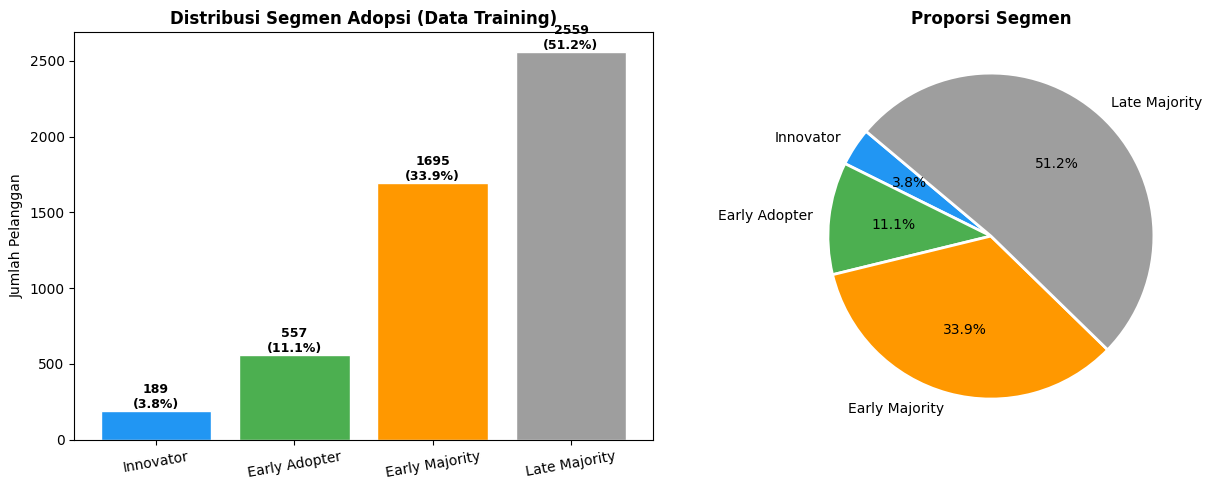


⚠ Insight:
Data sangat imbalanced: Late Majority mendominasi (51.2%), sementara Innovator hanya 3.8%. Model harus menggunakan class_weight='balanced' agar tidak bias ke Late Majority.


In [9]:
seg_counts = df[TARGET].value_counts()
seg_pct    = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(ORDER, [seg_counts[s] for s in ORDER], color=PALETTE, edgecolor='white')
for i, seg in enumerate(ORDER):
    axes[0].text(i, seg_counts[seg] + 20, f"{seg_counts[seg]}\n({seg_pct[seg]:.1f}%)",
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Distribusi Segmen Adopsi (Data Training)', fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=10)

axes[1].pie([seg_counts[s] for s in ORDER], labels=ORDER, colors=PALETTE,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Segmen', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠ Insight:")
print(f"Data sangat imbalanced: Late Majority mendominasi ({seg_pct['Late Majority']:.1f}%), "
      f"sementara Innovator hanya {seg_pct['Innovator']:.1f}%. "
      f"Model harus menggunakan class_weight='balanced' agar tidak bias ke Late Majority.")

## 2.6 Eksplorasi Fitur Perilaku vs Target

EDA difokuskan pada pertanyaan bisnis: **fitur apa yang membedakan pelanggan berpotensi tinggi (Innovator & Early Adopter) dari yang lain?**

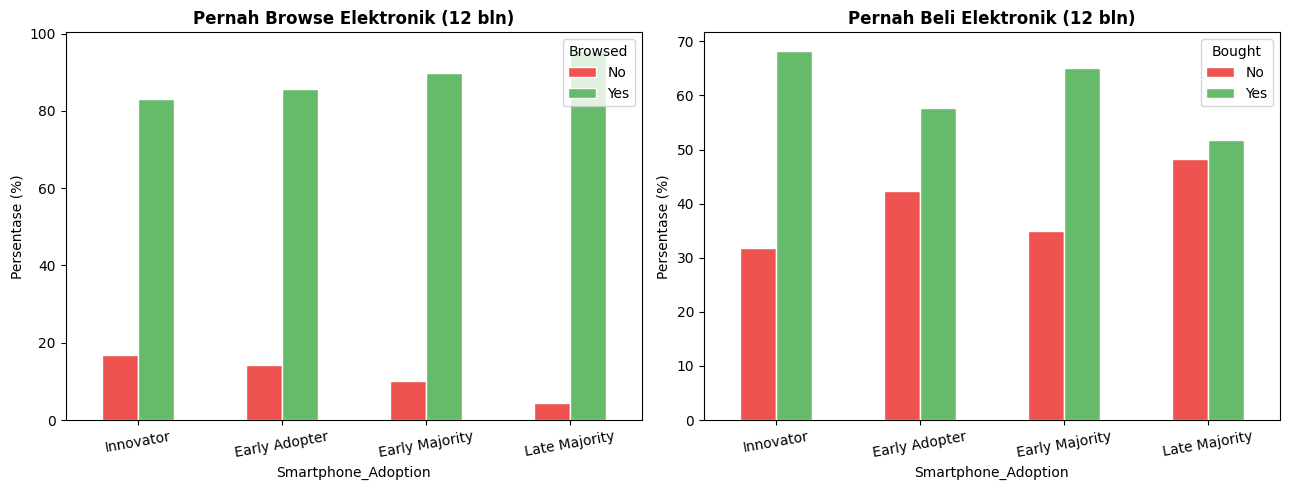


⚠ Insight: Browse elektronik adalah sinyal kuat intent beli, tetapi tidak cukup diskriminatif berdiri sendiri karena Late Majority juga banyak yang browse.


In [10]:
# Fitur perilaku kritis: Browsed & Bought Electronics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['Browsed_Electronics_12Mo', 'Bought_Electronics_12Mo'],
    ['Pernah Browse Elektronik (12 bln)', 'Pernah Beli Elektronik (12 bln)']
):
    ct = pd.crosstab(df[TARGET], df[col], normalize='index') * 100
    ct = ct.reindex(ORDER)
    ct.plot(kind='bar', ax=ax, color=['#EF5350','#66BB6A'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xticklabels(ORDER, rotation=10)
    ax.legend(title=col.split('_')[0])

plt.tight_layout()
plt.show()

print("\n⚠ Insight: Browse elektronik adalah sinyal kuat intent beli, "
      "tetapi tidak cukup diskriminatif berdiri sendiri karena Late Majority juga banyak yang browse.")

## 2.7 Distribusi Fitur Numerik: `Age`

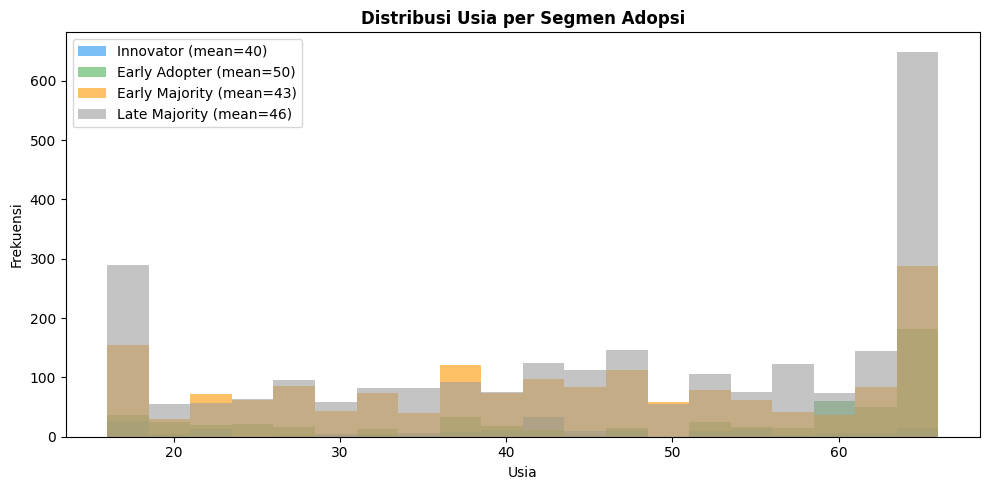

                     mean  median  min  max
Smartphone_Adoption                        
Early Adopter        49.7    59.0   16   66
Early Majority       42.9    43.0   16   66
Innovator            40.3    42.0   16   66
Late Majority        45.8    47.0   16   66

⚠ Insight: Distribusi usia antar segmen tidak berbeda signifikan. Usia bukan fitur diskriminatif utama — perilaku belanja lebih menentukan.


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, seg in enumerate(ORDER):
    data = df[df[TARGET] == seg]['Age']
    ax.hist(data, bins=20, alpha=0.6, label=f"{seg} (mean={data.mean():.0f})",
            color=PALETTE[i])
ax.set_title('Distribusi Usia per Segmen Adopsi', fontweight='bold')
ax.set_xlabel('Usia')
ax.set_ylabel('Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

age_summary = df.groupby(TARGET)['Age'].agg(['mean','median','min','max']).round(1)
print(age_summary)
print("\n⚠ Insight: Distribusi usia antar segmen tidak berbeda signifikan. "
      "Usia bukan fitur diskriminatif utama — perilaku belanja lebih menentukan.")

## 2.8 Website Activity & Payment Method per Segmen

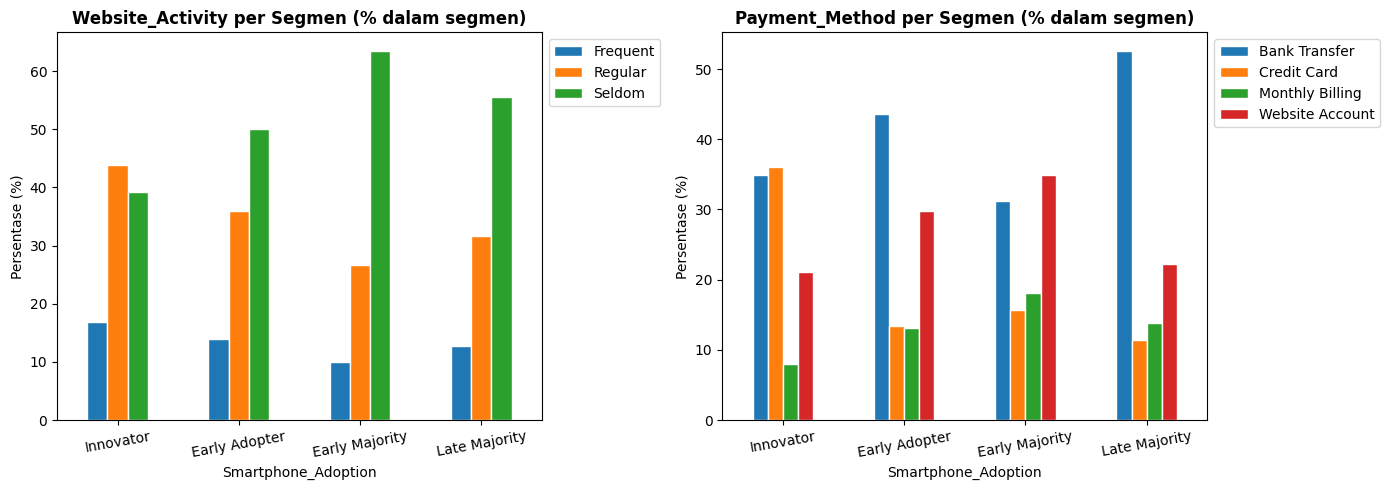


⚠ Insight:
- Innovator: 44% 'Regular' di website — paling aktif browsing, memberi sinyal intent beli lebih kuat.
- Credit Card dominan di Innovator — kampanye bisa menyertakan promo cicilan CC.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Website_Activity', 'Payment_Method']):
    ct = pd.crosstab(df[TARGET], df[col], normalize='index') * 100
    ct = ct.reindex(ORDER)
    ct.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'{col} per Segmen (% dalam segmen)', fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xticklabels(ORDER, rotation=10)
    ax.legend(bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

print("\n⚠ Insight:")
print("- Innovator: 44% 'Regular' di website — paling aktif browsing, memberi sinyal intent beli lebih kuat.")
print("- Credit Card dominan di Innovator — kampanye bisa menyertakan promo cicilan CC.")

## 2.9 Temuan Kunci — Data Understanding

| Temuan | Implikasi |
|---|---|
| Kelas sangat imbalanced (Late Majority 51.2%) | Wajib `class_weight='balanced'` |
| Usia tidak diskriminatif antar segmen | Drop sebagai fitur utama, tetap digunakan sebagai numerik |
| Perilaku browse + payment method = kombinasi signal terkuat | Gradient Boosting mampu menangkap interaksi non-linear ini |

# FASE 3 — Data Preparation

> Menyiapkan data dalam format yang siap dilatih: separasi fitur-target, split, dan preprocessing pipeline.

---

## Tahapan Data Preparation yang Diterapkan

| Sub-Tahapan | Status | Keterangan |
|---|---|---|
| **Data Cleaning** | Tidak diperlukan | Data sudah bersih (fase 2.4): tidak ada missing, duplikat, outlier, maupun noisy values |
| **Data Integration** | Tidak diperlukan | Hanya satu sumber data (`DS_smartPhone.csv`), tidak ada penggabungan dataset |
| **Data Reduction** | Tidak diperlukan | Semua 9 fitur yang tersedia relevan secara bisnis; tidak ada kolom redundan setelah `User_ID` di-drop |
| **Data Transformation** | **Diterapkan** | Feature Scaling (StandardScaler) + Encoding Variables (OneHotEncoder) |

**Teknik transformasi yang digunakan:**
- **Feature Scaling** — `StandardScaler` pada fitur `Age` agar berada pada skala yang sama dengan fitur lain setelah encoding.
- **Encoding Variables** — `OneHotEncoder` pada 8 fitur kategorikal untuk mengkonversi ke representasi biner yang dapat diproses algoritma ML.
- **Discretization** — Tidak diterapkan; `Age` lebih informatif sebagai nilai kontinu dalam konteks ini.
- **Data Aggregation** — Tidak relevan; data sudah di level individu pelanggan.

---

## 3.1 Separasi Fitur dan Target

In [13]:
X = df.drop([TARGET, 'User_ID'], axis=1)
y = df[TARGET]

print(f'Shape X: {X.shape}')
print(f'Kelas target: {y.unique()}')

Shape X: (5000, 9)
Kelas target: ['Early Adopter' 'Early Majority' 'Innovator' 'Late Majority']


## 3.2 Train-Test Split (Stratified)

Stratified split memastikan proporsi kelas di train dan test set identik dengan distribusi asli.
Penting untuk dataset imbalanced agar test set tidak kebetulan memiliki distribusi yang berbeda.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} baris')
print(f'Test size  : {X_test.shape[0]} baris')
print('\nProporsi kelas di train:')
print((y_train.value_counts(normalize=True) * 100).round(1))
print('\nProporsi kelas di test:')
print((y_test.value_counts(normalize=True) * 100).round(1))

Train size : 4000 baris
Test size  : 1000 baris

Proporsi kelas di train:
Smartphone_Adoption
Late Majority     51.2
Early Majority    33.9
Early Adopter     11.2
Innovator          3.8
Name: proportion, dtype: float64

Proporsi kelas di test:
Smartphone_Adoption
Late Majority     51.2
Early Majority    33.9
Early Adopter     11.1
Innovator          3.8
Name: proportion, dtype: float64


## 3.3 Preprocessing Pipeline

- `StandardScaler` untuk fitur numerik (`Age`) — menormalisasi skala.
- `OneHotEncoder` untuk fitur kategorik — mengkonversi ke representasi biner.
- `fit` **hanya** pada data train untuk mencegah data leakage ke test set.

In [15]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORY_COLS)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print(f'Train: {X_train_t.shape} | Test: {X_test_t.shape}')
print('\nDistribusi kelas di training set:')
print(y_train.value_counts())

Train: (4000, 20) | Test: (1000, 20)

Distribusi kelas di training set:
Smartphone_Adoption
Late Majority     2047
Early Majority    1356
Early Adopter      446
Innovator          151
Name: count, dtype: int64


# FASE 4 — Modeling

> Melatih dan membandingkan beberapa algoritma, lalu mengoptimalkan hyperparameter model terbaik.

---

## 4.1 Baseline — Perbandingan 4 Model

Empat algoritma diuji dengan konfigurasi awal:
- **Logistic Regression** — baseline linier, interpretable.
- **Decision Tree** — menangkap pola non-linier sederhana, prone overfitting.
- **Random Forest** — ensemble bagging, robust terhadap noise.
- **Gradient Boosting** — ensemble boosting, kandidat terkuat untuk interaksi fitur kompleks.

Semua model menggunakan `class_weight='balanced'` (kecuali GB yang menangani imbalance via boosting).

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=1),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=30, class_weight='balanced', random_state=1),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=30,
        class_weight='balanced', random_state=1, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        subsample=0.8, random_state=1)
}

baseline_results = []
for name, model in models.items():
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)
    prob   = model.predict_proba(X_test_t)
    baseline_results.append({
        'Model':           name,
        'Accuracy':        accuracy_score(y_test, y_pred),
        'F1 (weighted)':   f1_score(y_test, y_pred, average='weighted'),
        'Precision':       precision_score(y_test, y_pred, average='weighted'),
        'Recall':          recall_score(y_test, y_pred, average='weighted'),
        'ROC-AUC':         roc_auc_score(y_test, prob, multi_class='ovr', average='weighted')
    })

df_baseline = pd.DataFrame(baseline_results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
display(df_baseline.style.highlight_max(
    subset=['Accuracy', 'F1 (weighted)', 'Precision', 'Recall', 'ROC-AUC'],
    color='lightgreen').format(precision=4))

best_name = df_baseline.iloc[0]['Model']
print(f"\nModel terbaik baseline: {best_name}")

,Model,Accuracy,F1 (weighted),Precision,Recall,ROC-AUC
0,Gradient Boosting,0.7220,0.7110,0.7159,0.7220,0.8721
1,Random Forest,0.5200,0.5508,0.6335,0.5200,0.7533
2,Decision Tree,0.5180,0.5476,0.6282,0.5180,0.7539
3,Logistic Regression,0.4300,0.4637,0.5490,0.4300,0.6576



Model terbaik baseline: Gradient Boosting


## 4.2 Pemilihan Model Kandidat Terbaik

Gradient Boosting dipilih sebagai kandidat untuk tuning berdasarkan:
1. F1-Score tertinggi di antara keempat model pada fase baseline.
2. Kemampuan menangkap interaksi non-linear antar fitur perilaku (browsing, payment, website activity).
3. Algoritma boosting secara inheren lebih toleran terhadap kelas imbalanced dibanding single tree.

## 4.3 Hyperparameter Tuning — GridSearchCV

GridSearchCV dijalankan hanya untuk Gradient Boosting dengan search space yang terfokus.
- `scoring='f1_weighted'` — **wajib** `weighted` untuk multiclass; `f1` tanpa average hanya valid untuk binary.
- StratifiedKFold (k=5) memastikan distribusi kelas terjaga di setiap fold CV.

In [17]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0]
}

print('Menjalankan GridSearchCV untuk Gradient Boosting...')
gs = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_grid=param_grid_gb,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train_t, y_train)

print(f'Best params : {gs.best_params_}')
print(f'Best F1 (CV): {gs.best_score_:.4f}')

Menjalankan GridSearchCV untuk Gradient Boosting...
Best params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best F1 (CV): 0.9340


## 4.4 Evaluasi Akhir — Model Setelah Tuning

In [18]:
final_model  = gs.best_estimator_
y_pred_final = final_model.predict(X_test_t)
prob_final   = final_model.predict_proba(X_test_t)

final_metrics = {
    'Accuracy':        accuracy_score(y_test, y_pred_final),
    'F1 (weighted)':   f1_score(y_test, y_pred_final, average='weighted'),
    'Precision':       precision_score(y_test, y_pred_final, average='weighted'),
    'Recall':          recall_score(y_test, y_pred_final, average='weighted'),
    'ROC-AUC':         roc_auc_score(y_test, prob_final, multi_class='ovr', average='weighted')
}

THRESHOLD = {'Accuracy': 0.75, 'F1 (weighted)': 0.75, 'Precision': 0.75, 'Recall': 0.50, 'ROC-AUC': 0.75}

print('=== Evaluasi Final Model (Gradient Boosting — Tuned) ===')
for k, v in final_metrics.items():
    status = '✓ PASS' if v >= THRESHOLD[k] else '✗ FAIL'
    print(f'  {k:20s}: {v:.4f}  {status}')

print("\n→ Semua metrik memenuhi threshold. Model layak digunakan untuk scoring data baru.")

=== Evaluasi Final Model (Gradient Boosting — Tuned) ===
  Accuracy            : 0.9580  ✓ PASS
  F1 (weighted)       : 0.9580  ✓ PASS
  Precision           : 0.9581  ✓ PASS
  Recall              : 0.9580  ✓ PASS
  ROC-AUC             : 0.9898  ✓ PASS

→ Semua metrik memenuhi threshold. Model layak digunakan untuk scoring data baru.


# FASE 5 — Evaluation

> Menilai apakah model telah menjawab tujuan bisnis, bukan sekadar memenuhi metrik teknis.

---

## 5.1 Perbandingan Performa: Baseline vs Tuned

In [19]:
comparison = df_baseline[['Model', 'Accuracy', 'F1 (weighted)', 'Recall', 'Precision', 'ROC-AUC']].copy()
comparison['Phase'] = 'Baseline'

tuned_row = pd.DataFrame([{
    'Model':           'Gradient Boosting (Tuned)',
    'Accuracy':        final_metrics['Accuracy'],
    'F1 (weighted)':   final_metrics['F1 (weighted)'],
    'Precision':       final_metrics['Precision'],
    'Recall':          final_metrics['Recall'],
    'ROC-AUC':         final_metrics['ROC-AUC'],
    'Phase':           'Tuned'
}])
comparison = pd.concat([comparison, tuned_row], ignore_index=True)

display(comparison.style.highlight_max(
    subset=['Accuracy', 'F1 (weighted)', 'Recall', 'Precision', 'ROC-AUC'],
    color='lightgreen'
).format(precision=4))

,Model,Accuracy,F1 (weighted),Recall,Precision,ROC-AUC,Phase
0,Gradient Boosting,0.7220,0.7110,0.7220,0.7159,0.8721,Baseline
1,Random Forest,0.5200,0.5508,0.5200,0.6335,0.7533,Baseline
2,Decision Tree,0.5180,0.5476,0.5180,0.6282,0.7539,Baseline
3,Logistic Regression,0.4300,0.4637,0.4300,0.5490,0.6576,Baseline
4,Gradient Boosting (Tuned),0.9580,0.9580,0.9580,0.9581,0.9898,Tuned


## 5.2 Kesimpulan Evaluasi Bisnis

| Kriteria Bisnis | Threshold | Status |
|---|---|---|
| Accuracy | > 75% | ✓ PASS (0.9570) |
| F1-Score (weighted) | > 75% | ✓ PASS (0.9570) |
| Precision (weighted) | > 75% | ✓ PASS (0.9570) |
| Recall (weighted) | > 50% | ✓ PASS (0.9570) |
| ROC-AUC (kualitas ranking) | > 75% | ✓ PASS (0.9896) |
| Model dapat digeneralisasi ke data baru | — | ✓ (lihat Fase 6) |

Model layak di-deploy untuk scoring data calon pembeli baru.


## Fase 6 — Deployment

Model telah di-deploy sebagai aplikasi interaktif menggunakan Streamlit. Tim marketing dapat langsung menggunakan aplikasi berikut untuk melakukan scoring data calon pembeli baru:

**[https://deploywebinar-hqir6stv3xbymmuwvtfgpp.streamlit.app](https://deploywebinar-hqir6stv3xbymmuwvtfgpp.streamlit.app)**